<a href="https://colab.research.google.com/github/fabriciosantana/unb/blob/main/01-ppgi0034-redes-neurais-e-aprendizado-profundo/projetos/machado-assis/notebooks/04_comparativo_gpt_caractere_reduzido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento comparativo de capacidade reduzida GPT autorregressivo em nível de caractere (nanoGPT)

**Projeto:** RNAP 2026/2 — Machado de Assis


**Condição comparativa:** mantém dados, tokenização, contexto, orçamento e protocolo; muda conjuntamente a arquitetura para 4 camadas, 4 cabeças e dimensão 256. No `train.py` do commit fixado, a seed de treino é 1337 (uma GPU), enquanto `SEED=20260925` controla preparação/tokenizador e geração; SEED+1 controla a amostragem do teste. Portanto, não isola o efeito individual de cada dimensão arquitetural.
Este notebook prepara os dados em caracteres, usa o código oficial do **nanoGPT** em um commit fixado e treina um experimento comparativo de capacidade reduzida, com arquitetura causal pequena, do zero. A arquitetura segue o exemplo `shakespeare_char` do nanoGPT; o tokenizador é uma tabela de caracteres ajustada apenas no treino, com tokens reservados para fim de documento e caractere desconhecido. Portanto, não treinamos BPE nem afirmamos reproduzir o GPT-2 original em escala ou tokenização.

O enunciado da disciplina indica nanoGPT como código-base. O repositório agora se descreve como antigo/depreciado, então este notebook fixa o commit consultado e registra sua licença MIT. Na configuração padrão, o treino completo usa GPU; sem GPU, o notebook executa somente um teste curto de integração em CPU e deixa o treino completo para um ambiente Colab/GPU.

**Partições:** usamos `train.jsonl` e `validation.jsonl` durante o treino; `test.jsonl` só é aberto após o checkpoint final do treino existir. O arquivo salvo na iteração 5.000 é usado; não se afirma que seja o melhor checkpoint histórico por validação. A divisão por documento/obra foi feita no notebook 02. Mantemos cabeçalhos e notas editoriais conforme a preparação conservadora anterior.

Referências técnicas: [nanoGPT (README e código)](https://github.com/karpathy/nanoGPT), [GPT-2](https://openai.com/index/better-language-models/) e [Attention Is All You Need](https://arxiv.org/abs/1706.03762).

## Execução no Google Colab com persistência no Drive

1. Salve uma cópia deste notebook no seu Drive e selecione um runtime com GPU.
2. Execute primeiro o notebook 01 e depois o notebook 02, no mesmo Drive, para construir o corpus e as partições. Execute então a configuração inicial deste notebook e autorize a montagem do Drive. Cada execução recebe um identificador único e grava em `MyDrive/machado-gpt-treinamento-colab/novas_execucoes/<experimento>/<identificador>/`.
3. Os três JSONL gerados pelo notebook 02 devem estar em `MyDrive/machado-gpt-treinamento-colab/dados/modelagem/`; serão encontrados automaticamente e seus hashes serão conferidos. Se os arquivos não existirem, o notebook ainda permite enviá-los.
4. Execute as células em ordem. Configuração, tokenizador, cópias dos JSONL, ambiente, código-base, logs e curvas são preservados; `out/ckpt.pt` é atualizado a cada 500 iterações, mantendo o último checkpoint, não todos os estados históricos.
5. Execute avaliação e inventário ao terminar. Salve o notebook com suas saídas no Drive. Uma interrupção abrupta pode deixar o status como `running`; consulte o log e o último checkpoint. Não há retomada automática nesta versão.

Os dados binários usados a cada lote ficam no disco local para evitar leituras repetidas do Drive. Resultados históricos e artigo não são substituídos. Reexecutar a configuração inicial cria outra pasta; mantenha a mesma execução até terminar.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import hashlib
import json
import os
import pickle
import re
import shutil
import subprocess
import sys
import uuid

import numpy as np
import torch

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

EXPERIMENT_NAME = 'gpt_caractere_reduzido'
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "-" + uuid.uuid4().hex[:8]
SEED = 20260925
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    STORAGE_ROOT = Path("/content/drive/MyDrive/machado-gpt-treinamento-colab")
else:
    cwd = Path.cwd().resolve()
    MACHADO_DIR = next((p for p in (cwd, *cwd.parents) if p.name == "machado-assis"), None)
    if MACHADO_DIR is None:
        MACHADO_DIR = cwd / "projetos" / "machado-assis"
    if not MACHADO_DIR.is_dir():
        raise FileNotFoundError("Execute da raiz do workspace ou da pasta do projeto.")
    STORAGE_ROOT = MACHADO_DIR

# Os JSONL ficam no Drive; os binários de leitura intensiva ficam no disco local.
SPLIT_DIR = STORAGE_ROOT / "dados" / "modelagem"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR = STORAGE_ROOT / "novas_execucoes" / EXPERIMENT_NAME / RUN_ID
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=False)
WORK_DIR = Path("/tmp") / ("machado-" + EXPERIMENT_NAME + "-" + RUN_ID)
CHAR_DATA_DIR = WORK_DIR / "nanogpt_char"
CHAR_DATA_DIR.mkdir(parents=True, exist_ok=True)
NANOGPT_URL = "https://github.com/karpathy/nanoGPT.git"
NANOGPT_COMMIT = "3adf61e154c3fe3fca428ad6bc3818b27a3b8291"
NANOGPT_DIR = WORK_DIR / "nanoGPT"
EXPECTED_SPLIT_SHA256 = {'train': '7861c68efe705531455db51f5fee6f3a8e58347e2419b8f1a6cf62c642997279', 'validation': '8c858a992c05ff6a434d39279313031d323b9ddd88b6e1fd0200b613a92efdb8', 'test': '39921df0e05297cf2137f8e646fd9bc67814f8b32a479ef1d13a49fa5c4664f2'}

def save_json(path, data):
    path.write_text(json.dumps(data, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

environment = {
    "run_id": RUN_ID, "experiment": EXPERIMENT_NAME,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "python": sys.version, "pytorch": str(torch.__version__),
    "cuda_version": torch.version.cuda, "device": DEVICE,
    "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else None,
    "nanoGPT_commit": NANOGPT_COMMIT,
    "training_seed": 1337, "preparation_generation_seed": SEED,
    "test_window_seed": SEED + 1,
}
save_json(EXPERIMENT_DIR / "ambiente.json", environment)
freeze = subprocess.run([sys.executable, "-m", "pip", "freeze"], capture_output=True, text=True, check=True)
(EXPERIMENT_DIR / "requirements-executado.txt").write_text(freeze.stdout, encoding="utf-8")
print("Execução:", RUN_ID)
print("Dispositivo:", DEVICE, environment["gpu"])
print("Dados:", SPLIT_DIR)
print("Resultados persistentes:", EXPERIMENT_DIR)
if DEVICE == "cpu":
    print("Sem GPU: apenas teste curto de integração; não produz resultado experimental.")


Mounted at /content/drive
Execução: 20260928T232621Z-f4c538e9
Dispositivo: cuda Tesla T4
Dados: /content/drive/MyDrive/machado-gpt-treinamento-colab/dados/modelagem
Resultados persistentes: /content/drive/MyDrive/machado-gpt-treinamento-colab/novas_execucoes/gpt_caractere_reduzido/20260928T232621Z-f4c538e9


## 1. Obter e fixar o código-base nanoGPT

In [2]:
if not NANOGPT_DIR.exists():
    NANOGPT_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "init", str(NANOGPT_DIR)], check=True, capture_output=True, text=True)
    subprocess.run(["git", "-C", str(NANOGPT_DIR), "remote", "add", "origin", NANOGPT_URL], check=True)
    subprocess.run(["git", "-C", str(NANOGPT_DIR), "fetch", "--depth", "1", "origin", NANOGPT_COMMIT], check=True)
    subprocess.run(["git", "-C", str(NANOGPT_DIR), "checkout", "--detach", "FETCH_HEAD"], check=True)

actual_commit = subprocess.run(
    ["git", "-C", str(NANOGPT_DIR), "rev-parse", "HEAD"],
    check=True, capture_output=True, text=True
).stdout.strip()
assert actual_commit == NANOGPT_COMMIT, (actual_commit, NANOGPT_COMMIT)
license_path = NANOGPT_DIR / "LICENSE"
assert license_path.exists(), "Licença do código-base não encontrada."
print("nanoGPT commit:", actual_commit)
print("Licença presente:", license_path)
print("Código de treino:", NANOGPT_DIR / "train.py")

# Arquivo exato do código-base usado, com licença, independente do clone temporário.
subprocess.run(["git", "-C", str(NANOGPT_DIR), "archive", "--format=zip",
                "--output=" + str(EXPERIMENT_DIR / "nanogpt_codigo.zip"), NANOGPT_COMMIT], check=True)


nanoGPT commit: 3adf61e154c3fe3fca428ad6bc3818b27a3b8291
Licença presente: /tmp/machado-gpt_caractere_reduzido-20260928T232621Z-f4c538e9/nanoGPT/LICENSE
Código de treino: /tmp/machado-gpt_caractere_reduzido-20260928T232621Z-f4c538e9/nanoGPT/train.py


CompletedProcess(args=['git', '-C', '/tmp/machado-gpt_caractere_reduzido-20260928T232621Z-f4c538e9/nanoGPT', 'archive', '--format=zip', '--output=/content/drive/MyDrive/machado-gpt-treinamento-colab/novas_execucoes/gpt_caractere_reduzido/20260928T232621Z-f4c538e9/nanogpt_codigo.zip', '3adf61e154c3fe3fca428ad6bc3818b27a3b8291'], returncode=0)

## 2. Ajustar o tokenizador de caracteres somente no treino

In [3]:
split_paths = {name: SPLIT_DIR / f"{name}.jsonl" for name in ("train", "validation", "test")}
missing = [name for name, path in split_paths.items() if not path.exists()]
if missing and IN_COLAB:
    from google.colab import files
    print("Selecione train.jsonl, validation.jsonl e test.jsonl da pasta dados/modelagem do projeto.")
    uploaded = files.upload()
    for filename, contents in uploaded.items():
        if filename in {path.name for path in split_paths.values()}:
            (SPLIT_DIR / filename).write_bytes(contents)
    missing = [name for name, path in split_paths.items() if not path.exists()]
if missing:
    expected = ", ".join(path.name for path in split_paths.values())
    raise FileNotFoundError(
        f"Faltam {missing}. Coloque os arquivos {expected} em {SPLIT_DIR}; "
        "no Colab, a janela de upload aceita os três arquivos."
    )

# Preserva os arquivos exatos; o conteúdo do teste não participa do tokenizador/treino.
input_manifest = {}
for split, path in split_paths.items():
    digest = sha256_file(path)
    if digest != EXPECTED_SPLIT_SHA256[split]:
        raise ValueError(f"Partição {split} difere do experimento original. Use os JSONL originais desta comparação.")
    snapshot = EXPERIMENT_DIR / "dados" / path.name
    snapshot.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(path, snapshot)
    input_manifest[split] = {"file": str(snapshot.relative_to(EXPERIMENT_DIR)), "sha256": digest}
save_json(EXPERIMENT_DIR / "manifesto_dados.json", input_manifest)
# Treino e teste leem as cópias congeladas desta execução.
split_paths = {split: EXPERIMENT_DIR / info["file"] for split, info in input_manifest.items()}

def read_jsonl_documents(path):
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

documents = {name: read_jsonl_documents(split_paths[name]) for name in ("train", "validation")}
assert documents["train"] and documents["validation"]

# O vocabulário é aprendido exclusivamente no treino. UNK cobre caracteres
# raros exclusivos da validação/teste; EOS marca o limite de cada arquivo.
train_characters = sorted(set("".join(doc["text"] for doc in documents["train"])))
EOS = "<|eos|>"
UNK = "<|unk|>"
itos = train_characters + [EOS, UNK]
stoi = {token: idx for idx, token in enumerate(itos)}
assert len(itos) <= 65536, "uint16 não comporta este vocabulário."
eos_id, unk_id = stoi[EOS], stoi[UNK]

def encode_documents(docs):
    ids = []
    unknown = 0
    for doc in docs:
        for char in doc["text"]:
            idx = stoi.get(char, unk_id)
            unknown += idx == unk_id
            ids.append(idx)
        ids.append(eos_id)
    return np.asarray(ids, dtype=np.uint16), unknown

encoded = {}
unknown_counts = {}
for split, docs in documents.items():
    encoded[split], unknown_counts[split] = encode_documents(docs)
    filename = "val.bin" if split == "validation" else "train.bin"
    encoded[split].tofile(CHAR_DATA_DIR / filename)
# Não deixamos um artefato de teste de execução anterior acessível ao treino.
test_bin_path = CHAR_DATA_DIR / "test.bin"
if test_bin_path.exists():
    test_bin_path.unlink()

meta = {
    "vocab_size": len(itos),
    "itos": itos,
    "stoi": stoi,
    "eos_token": EOS,
    "eos_id": eos_id,
    "unk_token": UNK,
    "unk_id": unk_id,
    "tokenizer": "character-level; vocabulary fitted on train documents only",
    "training_source": "train.jsonl",
    "seed": SEED,
}
with (CHAR_DATA_DIR / "meta.pkl").open("wb") as f:
    pickle.dump(meta, f)

print("Tamanho do vocabulário:", len(itos), "(caracteres + EOS + UNK)")
print("IDs de treino/validação:", {k: len(v) for k, v in encoded.items()})
print("Caracteres mapeados para UNK em treino/validação:", unknown_counts)
print("Dados binários em:", CHAR_DATA_DIR)
assert len(encoded["train"]) > 256 and len(encoded["validation"]) > 256

shutil.copy2(CHAR_DATA_DIR / "meta.pkl", EXPERIMENT_DIR / "meta.pkl")


Tamanho do vocabulário: 147 (caracteres + EOS + UNK)
IDs de treino/validação: {'train': 11113894, 'validation': 1340703}
Caracteres mapeados para UNK em treino/validação: {'train': 0, 'validation': 2}
Dados binários em: /tmp/machado-gpt_caractere_reduzido-20260928T232621Z-f4c538e9/nanogpt_char


PosixPath('/content/drive/MyDrive/machado-gpt-treinamento-colab/novas_execucoes/gpt_caractere_reduzido/20260928T232621Z-f4c538e9/meta.pkl')

## 3. Configurar o nanoGPT

A configuração principal é uma variante reduzida do modelo pequeno de caracteres documentado pelo nanoGPT (4 camadas, 4 cabeças, embedding 256, contexto de 256 caracteres). É um experimento comparativo educacional ajustado ao corpus, não uma reprodução do GPT‑2 original. Para cada execução registramos hiperparâmetros e semente.


In [4]:
OUT_DIR = EXPERIMENT_DIR / "out"
CONFIG_PATH = NANOGPT_DIR / "config" / "train_machado_char.py"
CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)

config_text = f'''# Configuração do projeto RNAP — derivada do padrão train_shakespeare_char do nanoGPT.
out_dir = r"{OUT_DIR}"
eval_interval = 500
log_interval = 50
eval_iters = 100
eval_only = False
always_save_checkpoint = True
init_from = "scratch"
dataset = "machado_assis_char"
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 4
n_head = 4
n_embd = 256
dropout = 0.1
bias = False
learning_rate = 3e-4
max_iters = 5000
weight_decay = 0.1
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0
decay_lr = True
warmup_iters = 100
lr_decay_iters = 5000
min_lr = 3e-5
backend = "nccl"
device = "cuda"
dtype = "float16"
compile = False
'''
CONFIG_PATH.write_text(config_text, encoding="utf-8")
(EXPERIMENT_DIR / "config_train_machado_char.py").write_text(config_text, encoding="utf-8")

# nanoGPT espera data/<dataset> dentro do clone; usa os .bin acima sem duplicar.
NANOGPT_DATA_DIR = NANOGPT_DIR / "data" / "machado_assis_char"
NANOGPT_DATA_DIR.mkdir(parents=True, exist_ok=True)
for name in ("train.bin", "val.bin", "meta.pkl"):
    source = CHAR_DATA_DIR / name
    target = NANOGPT_DATA_DIR / name
    if target.exists() or target.is_symlink():
        target.unlink()
    target.symlink_to(source)
print("Configuração:", CONFIG_PATH)
print("Pasta de dados lida pelo nanoGPT:", NANOGPT_DATA_DIR)
print(config_text)


Configuração: /tmp/machado-gpt_caractere_reduzido-20260928T232621Z-f4c538e9/nanoGPT/config/train_machado_char.py
Pasta de dados lida pelo nanoGPT: /tmp/machado-gpt_caractere_reduzido-20260928T232621Z-f4c538e9/nanoGPT/data/machado_assis_char
# Configuração do projeto RNAP — derivada do padrão train_shakespeare_char do nanoGPT.
out_dir = r"/content/drive/MyDrive/machado-gpt-treinamento-colab/novas_execucoes/gpt_caractere_reduzido/20260928T232621Z-f4c538e9/out"
eval_interval = 500
log_interval = 50
eval_iters = 100
eval_only = False
always_save_checkpoint = True
init_from = "scratch"
dataset = "machado_assis_char"
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 4
n_head = 4
n_embd = 256
dropout = 0.1
bias = False
learning_rate = 3e-4
max_iters = 5000
weight_decay = 0.1
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0
decay_lr = True
warmup_iters = 100
lr_decay_iters = 5000
min_lr = 3e-5
backend = "nccl"
device = "cuda"
dtype = "float16"
compile = False



## 4. Treinamento com logs persistentes

A saída completa é gravada em `treinamento.log`; perdas de treino/validação a cada 500 iterações são gravadas em `curvas_perda.csv`. O checkpoint é escrito diretamente na pasta desta execução. A seleção permanece o checkpoint da iteração 5.000, para manter o protocolo original.


In [5]:
# Uma execução de treino por pasta: reexecutar esta célula não sobrescreve logs.
RUN_FULL_TRAINING = torch.cuda.is_available()
STATUS_PATH = EXPERIMENT_DIR / "status_treino.json"
if STATUS_PATH.exists():
    raise RuntimeError("Esta execução já foi iniciada. Consulte status/logs; para novo treino, reexecute a configuração inicial.")

if RUN_FULL_TRAINING:
    command = [sys.executable, "-u", "train.py", str(CONFIG_PATH)]
else:
    command = [
        sys.executable, "-u", "train.py", str(CONFIG_PATH),
        "--out_dir=" + str(EXPERIMENT_DIR / "smoke_cpu"),
        "--device=cpu", "--dtype=float32", "--compile=False",
        "--max_iters=2", "--lr_decay_iters=2", "--warmup_iters=1",
        "--eval_interval=1", "--eval_iters=1", "--log_interval=1",
        "--batch_size=2", "--block_size=32", "--n_layer=2", "--n_head=2", "--n_embd=64",
        "--gradient_accumulation_steps=1", "--dropout=0.0",
    ]

status = {"status": "running", "full_training": RUN_FULL_TRAINING,
          "command": command, "started_utc": datetime.now(timezone.utc).isoformat()}
save_json(STATUS_PATH, status)
pattern = re.compile(r"^step (\d+): train loss ([\d.eE+-]+), val loss ([\d.eE+-]+)")
process = None
try:
    with (EXPERIMENT_DIR / "treinamento.log").open("x", encoding="utf-8", buffering=1) as log, \
         (EXPERIMENT_DIR / "curvas_perda.csv").open("x", encoding="utf-8", newline="", buffering=1) as curve:
        writer = csv.writer(curve)
        writer.writerow(["iteration", "train_loss", "validation_loss"])
        process = subprocess.Popen(command, cwd=NANOGPT_DIR, stdout=subprocess.PIPE,
                                   stderr=subprocess.STDOUT, text=True, bufsize=1)
        for line in process.stdout:
            print(line, end="", flush=True)
            log.write(line)
            log.flush()
            match = pattern.match(line)
            if match:
                writer.writerow(match.groups())
                curve.flush()
        returncode = process.wait()
        if returncode:
            raise subprocess.CalledProcessError(returncode, command)
    if RUN_FULL_TRAINING:
        assert (OUT_DIR / "ckpt.pt").exists(), "Checkpoint não encontrado."
    status["status"] = "completed" if RUN_FULL_TRAINING else "smoke_completed"
except BaseException as exc:
    status["status"] = "interrupted" if isinstance(exc, KeyboardInterrupt) else "failed"
    status["error"] = repr(exc)
    if process is not None and process.poll() is None:
        process.terminate()
        try:
            process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait()
    raise
finally:
    status["finished_utc"] = datetime.now(timezone.utc).isoformat()
    save_json(STATUS_PATH, status)
print("Status:", status["status"])
print("Logs, curvas e checkpoint em:", EXPERIMENT_DIR)


Overriding config with /tmp/machado-gpt_caractere_reduzido-20260928T232621Z-f4c538e9/nanoGPT/config/train_machado_char.py:
# Configuração do projeto RNAP — derivada do padrão train_shakespeare_char do nanoGPT.
out_dir = r"/content/drive/MyDrive/machado-gpt-treinamento-colab/novas_execucoes/gpt_caractere_reduzido/20260928T232621Z-f4c538e9/out"
eval_interval = 500
log_interval = 50
eval_iters = 100
eval_only = False
always_save_checkpoint = True
init_from = "scratch"
dataset = "machado_assis_char"
gradient_accumulation_steps = 1
batch_size = 64
block_size = 256
n_layer = 4
n_head = 4
n_embd = 256
dropout = 0.1
bias = False
learning_rate = 3e-4
max_iters = 5000
weight_decay = 0.1
beta1 = 0.9
beta2 = 0.95
grad_clip = 1.0
decay_lr = True
warmup_iters = 100
lr_decay_iters = 5000
min_lr = 3e-5
backend = "nccl"
device = "cuda"
dtype = "float16"
compile = False

tokens per iteration will be: 16,384
found vocab_size = 147 (inside data/machado_assis_char/meta.pkl)
Initializing a new model from sc

## 5. Avaliação final e amostras (após treino completo em GPU)

In [6]:
checkpoint_path = OUT_DIR / "ckpt.pt"
if not checkpoint_path.exists():
    print("Avaliação final ainda não executada: falta checkpoint do treino completo. Rode a seção 4 com GPU CUDA.")
else:
    status = json.loads((EXPERIMENT_DIR / "status_treino.json").read_text())
    if status["status"] != "completed":
        raise RuntimeError("Treinamento completo não concluído; não avaliar checkpoint parcial no teste.")
    if str(NANOGPT_DIR) not in sys.path:
        sys.path.insert(0, str(NANOGPT_DIR))
    from model import GPT, GPTConfig

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    assert checkpoint["iter_num"] == 5000, "A avaliação exige o checkpoint da iteração 5000."
    model_args = checkpoint["model_args"]
    model = GPT(GPTConfig(**model_args)).to(device)
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in checkpoint["model"].items()}
    model.load_state_dict(state_dict)
    model.eval()
    block_size = model_args["block_size"]

    # O teste só é lido e codificado depois que o checkpoint foi produzido.
    test_documents = read_jsonl_documents(split_paths["test"])
    test_encoded, unknown_test_characters = encode_documents(test_documents)
    test_tokens = test_encoded.astype(np.int64)
    print("Documentos de teste abertos somente após o treino:", len(test_documents))
    rng = np.random.default_rng(SEED + 1)
    valid_starts = len(test_tokens) - block_size - 1
    assert valid_starts > 0
    eval_batches = 200
    batch_size = 32  # protocolo: 200 x 32 = 6.400 janelas em qualquer dispositivo
    micro_batch_size = 32 if device.type == "cuda" else 8
    sampled_starts = []
    losses = []
    with torch.no_grad():
        for _ in range(eval_batches):
            starts = rng.integers(0, valid_starts, size=batch_size)
            sampled_starts.extend(starts.tolist())
            weighted_loss = 0.0
            for offset in range(0, batch_size, micro_batch_size):
                micro_starts = starts[offset:offset + micro_batch_size]
                x = torch.stack([torch.from_numpy(test_tokens[s:s+block_size]) for s in micro_starts]).to(device)
                y = torch.stack([torch.from_numpy(test_tokens[s+1:s+block_size+1]) for s in micro_starts]).to(device)
                _, loss = model(x, y)
                weighted_loss += float(loss.item()) * len(micro_starts)
            losses.append(weighted_loss / batch_size)
    test_loss = float(np.mean(losses))
    test_perplexity = float(np.exp(test_loss))

    # Guarda o sorteio exato para conferir a comparação entre configurações.
    np.save(EXPERIMENT_DIR / "inicios_janelas_teste.npy", np.asarray(sampled_starts, dtype=np.int64))
    save_json(EXPERIMENT_DIR / "perdas_lotes_teste.json", losses)

    # Gera 700 tokens; a apresentação é truncada no primeiro EOS.
    prompt = "Era "
    prompt_ids = [stoi.get(ch, unk_id) for ch in prompt]
    idx = torch.tensor([prompt_ids], dtype=torch.long, device=device)
    torch.manual_seed(SEED)
    with torch.no_grad():
        generated = model.generate(idx, max_new_tokens=700, temperature=0.8, top_k=40)[0].tolist()
    generated = generated[len(prompt_ids):]
    if eos_id in generated:
        generated = generated[:generated.index(eos_id)]
    sample = "".join(itos[token] if token < len(itos)-2 else "�" for token in generated)
    sample_text = prompt + sample
    print(f"Test loss (nats/token, estimativa em {eval_batches} batches): {test_loss:.4f}")
    print(f"Perplexidade (tokens de caracteres + EOS/UNK): {test_perplexity:.3f}")
    print("\nAmostra gerada (qualitativa; não é avaliação humana):\n")
    print(sample_text)

    results = {
        "nanoGPT_commit": NANOGPT_COMMIT,
        "run_id": RUN_ID,
        "environment": environment,
        "evaluation_device": str(device),
        "evaluation_seed": SEED + 1,
        "evaluation_windows": len(sampled_starts),
        "micro_batch_size": micro_batch_size,
        "checkpoint_iteration": checkpoint["iter_num"],
        "seed": SEED,
        "model_args": model_args,
        "train_documents": len(documents["train"]),
        "validation_documents": len(documents["validation"]),
        "test_documents": len(test_documents),
        "vocab_size": len(itos),
        "unknown_test_characters": unknown_test_characters,
        "test_loss_nats_per_character_sampled": test_loss,
        "test_perplexity_per_character_sampled": test_perplexity,
        "evaluation_batches": eval_batches,
        "batch_size": batch_size,
        "sample_prompt": prompt,
        "sample_text": sample_text,
        "checkpoint": str(checkpoint_path),
    }
    (EXPERIMENT_DIR / "resultados_comparativo_reduzido.json").write_text(
        json.dumps(results, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
    )
    (EXPERIMENT_DIR / "amostra_gerada.txt").write_text(sample_text + "\n", encoding="utf-8")
    print("Resultados registrados em:", EXPERIMENT_DIR)


number of parameters: 3.19M
Documentos de teste abertos somente após o treino: 31
Test loss (nats/token, estimativa em 200 batches): 1.3862
Perplexidade (tokens de caracteres + EOS/UNK): 4.000

Amostra gerada (qualitativa; não é avaliação humana):

Era casa de sua esperança responder as duas
amizas, esse começava uma viva, e consolou-me a carta da realidade da minha carta,
que lhe pudera pela despedir divinar a cadeira um ar de tendência, e se ele
sonho acabado.

— Sim, repetiu Bom com isso mesmo.

— Pois também foi mil
concedente a manhã a noite, e que seja
esta resposta e inclinação sonhava o reconhecimento por antes, e falou o estado processo
da missão do meu meu rapaz.

— Que sei definitivo.

— Dê maior da filha
simplicação; tenho de leitor?

— Não preparar.

— Nem nenhuma coisa é que me podes
aceitar a não são verdadeiras por estranho.

— Não é excelente, não resistiu
grande que por que D. Quando uma coisa de sua arante.

— Oh! senhor
Resultados registrados em: /content/drive/MyDr

## 6. Curvas e inventário dos artefatos

Os arquivos já foram persistidos na pasta desta execução. Esta célula salva a figura das curvas e o inventário com hashes. Salve também o próprio notebook com suas saídas no Drive.


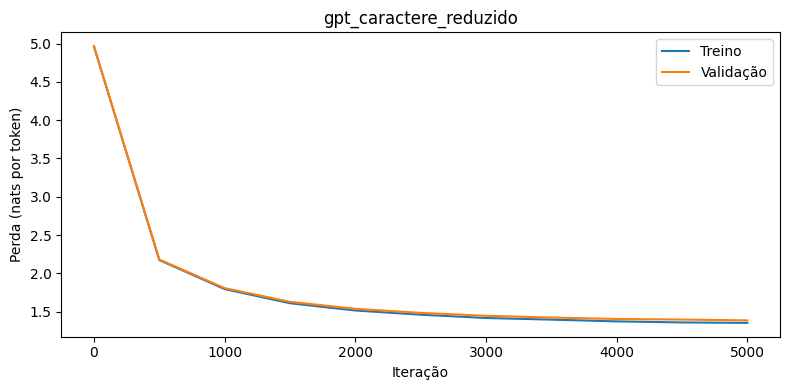

Pasta da execução: /content/drive/MyDrive/machado-gpt-treinamento-colab/novas_execucoes/gpt_caractere_reduzido/20260928T232621Z-f4c538e9
ambiente.json 465 bytes
amostra_gerada.txt 739 bytes
config_train_machado_char.py 747 bytes
curvas_perda.csv 254 bytes
curvas_perda.png 49197 bytes
dados/test.jsonl 1325011 bytes
dados/train.jsonl 11821395 bytes
dados/validation.jsonl 1427693 bytes
inicios_janelas_teste.npy 51328 bytes
manifesto_dados.json 407 bytes
meta.pkl 1474 bytes
nanogpt_codigo.zip 439351 bytes
out/ckpt.pt 39045964 bytes
perdas_lotes_teste.json 4352 bytes
requirements-executado.txt 14079 bytes
resultados_comparativo_reduzido.json 2215 bytes
status_treino.json 335 bytes
treinamento.log 8244 bytes
Salve também uma cópia deste notebook no Drive, com as saídas, pelo menu do Colab.


In [7]:
# Os artefatos já estão no Drive quando IN_COLAB=True; nenhum download é necessário.
curve_path = EXPERIMENT_DIR / "curvas_perda.csv"
if curve_path.exists():
    import matplotlib.pyplot as plt
    with curve_path.open(encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    if rows:
        fig, ax = plt.subplots(figsize=(8, 4))
        steps = [int(row["iteration"]) for row in rows]
        ax.plot(steps, [float(row["train_loss"]) for row in rows], label="Treino")
        ax.plot(steps, [float(row["validation_loss"]) for row in rows], label="Validação")
        ax.set(xlabel="Iteração", ylabel="Perda (nats por token)", title=EXPERIMENT_NAME)
        ax.legend()
        fig.tight_layout()
        fig.savefig(EXPERIMENT_DIR / "curvas_perda.png", dpi=160)
        plt.show()
        plt.close(fig)

inventory = {str(p.relative_to(EXPERIMENT_DIR)): {"bytes": p.stat().st_size, "sha256": sha256_file(p)}
             for p in sorted(EXPERIMENT_DIR.rglob("*")) if p.is_file() and p.name != "manifesto_artefatos.json"}
save_json(EXPERIMENT_DIR / "manifesto_artefatos.json", inventory)
print("Pasta da execução:", EXPERIMENT_DIR)
for name, info in inventory.items():
    print(name, info["bytes"], "bytes")
print("Salve também uma cópia deste notebook no Drive, com as saídas, pelo menu do Colab.")


## Interpretação e limites

- A perplexidade é **por caractere**; não é diretamente comparável com valores de tokenização BPE.
- A estimativa usa 200 lotes de 32 janelas de contexto 256, sorteadas com `default_rng(20260926)` do fluxo de teste concatenado (em CPU, cada lote lógico de 32 é processado em quatro partes de 8, mantendo as mesmas 6.400 janelas). Não é uma varredura de todos os caracteres; a janela pode conter EOS entre documentos.
- O `train.py` fixado define seed de treino 1337 para execução de uma GPU. `SEED=20260925` é usada na preparação/tokenizador e geração; `SEED+1` orienta a amostragem do teste.
- `always_save_checkpoint=True` grava `ckpt.pt` nos pontos de avaliação; o arquivo final é o checkpoint da iteração 5000 e o checkpoint final continua sendo o da iteração 5000, mesmo com a curva agora preservada.
- Os experimentos mudam três componentes de capacidade em conjunto. Resultados comparam configurações, não estabelecem causalidade isolada para camada, cabeça ou dimensão. O orçamento em atualizações é igual, não FLOPs nem tempo.
- O teste foi consultado depois do treino, mas o resultado do baseline foi conhecido antes da definição/execução da variante reduzida; portanto a segunda condição não deve ser descrita como totalmente pré-registrada sem acesso ao teste.
- O corpus continua versão de trabalho, sem alegação de exaustividade bibliográfica. A amostra é inspeção qualitativa, não avaliação humana.
